In [360]:
import pandas as pd
import os
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import seaborn as sns

In [361]:
files = os.listdir("events")
os.makedirs(name='shotprofile', exist_ok=True)

print(len(files))
print(files[:5])

4235
['15946.json', '15956.json', '15973.json', '15978.json', '15986.json']


In [362]:
comps = pd.read_json("data/competitions.json")
ucl = comps[comps["competition_id"] == 16]
print(ucl[["season_id", "season_name"]])    

    season_id season_name
3           4   2018/2019
4           1   2017/2018
5           2   2016/2017
6          27   2015/2016
7          26   2014/2015
8          25   2013/2014
9          24   2012/2013
10         23   2011/2012
11         22   2010/2011
12         21   2009/2010
13         41   2008/2009
14         39   2006/2007
15         37   2004/2005
16         44   2003/2004
17         76   1999/2000
18        277   1972/1973
19         71   1971/1972
20        276   1970/1971


In [363]:
seasons = [41,21,22,23,24,25,26,27,2,1,4]

In [364]:
def get_matches(season_ids):
    dfs = []

    for id in season_ids:
        df = pd.read_json(f"data/matches/16/{id}.json")
        dfs.append(df)

    matches = pd.concat(dfs, ignore_index=True)

    return set(matches["match_id"])

In [365]:
match_ids = get_matches(seasons)
files = [
    f for f in files
    if int(f.replace(".json", "")) in match_ids
]

print(len(files))
print()


11



In [366]:
allshots= []

for file in files:
    df = pd.read_json(f"events/{file}")

    shots = df[df["type"].apply(lambda x: x["name"] == "Shot")].copy()

    shots = shots[shots["period"] != 5]
    
    shots["match_id"] = int(file.replace(".json", ""))
    shots["x"] = shots["location"].apply(lambda x: x[0])
    shots["y"] = shots["location"].apply(lambda x: x[1])
    
    shots["xg"] = shots["shot"].apply(lambda x: x["statsbomb_xg"])
    shots["outcome"] = shots["shot"].apply(lambda x: x["outcome"]['name'])
    shots["player_name"] = shots["player"].apply(lambda x: x["name"])
    
    allshots.append(shots[["match_id", "player_name","xg","outcome","x","y"]])

allshots = pd.concat(allshots, ignore_index=True)


print(allshots["player_name"].value_counts())

player_name
Cristiano Ronaldo dos Santos Aveiro    30
Arjen Robben                           26
Gareth Frank Bale                      16
Lionel Andrés Messi Cuccittini         10
Thomas Müller                          10
                                       ..
Fábio Henrique Tavares                  1
Samuel Eto''o Fils                      1
Ji-Sung Park                            1
Harry Kane                              1
Divock Okoth Origi                      1
Name: count, Length: 114, dtype: int64


In [367]:
print(allshots.columns)

Index(['match_id', 'player_name', 'xg', 'outcome', 'x', 'y'], dtype='object')


In [368]:
print(allshots["player_name"].nunique())
print(allshots["player_name"].value_counts().head(10))

114
player_name
Cristiano Ronaldo dos Santos Aveiro    30
Arjen Robben                           26
Gareth Frank Bale                      16
Lionel Andrés Messi Cuccittini         10
Thomas Müller                          10
Toni Kroos                              8
Mohamed Salah                           8
Andrés Iniesta Luján                    7
Karim Benzema                           7
Luis Alberto Suárez Díaz                7
Name: count, dtype: int64


In [369]:
print(len(allshots))

355


In [370]:
(allshots['outcome'] == 'Goal').sum()

np.int64(35)

In [371]:
player_counts = allshots['player_name'].value_counts()
valid_players = player_counts[player_counts >= 5].index

all_shots = allshots[allshots['player_name'].isin(valid_players)]

In [372]:
all_shots

,match_id,player_name,xg,outcome,x,y
4,18235,Wesley Sneijder,0.008091,Saved,81.0,30.0
6,18235,Arjen Robben,0.069697,Off T,104.0,41.0
7,18235,Wesley Sneijder,0.005588,Saved,80.0,33.0
8,18235,Thomas Müller,0.029828,Off T,91.0,40.0
9,18235,Wesley Sneijder,0.089763,Wayward,111.0,51.0
...,...,...,...,...,...,...
343,3750201,Andrés Iniesta Luján,0.026691,Blocked,89.8,44.4
345,3750201,Xavier Hernández Creus,0.089694,Post,100.6,38.6
347,3750201,Lionel Andrés Messi Cuccittini,0.232887,Goal,113.8,36.9
349,3750201,Cristiano Ronaldo dos Santos Aveiro,0.371813,Saved,115.5,33.8


In [373]:
# max xg
print(all_shots.groupby('player_name').size().idxmax())
print(all_shots['player_name'].value_counts().max())

Cristiano Ronaldo dos Santos Aveiro
30


In [374]:
print(all_shots.groupby('player_name')['xg'].sum().idxmax())
print(all_shots['xg'].max().round(4))

Cristiano Ronaldo dos Santos Aveiro
0.7835


In [375]:
goals = (all_shots['outcome'] == 'Goal').groupby(all_shots['player_name']).sum()
xg = all_shots.groupby('player_name')['xg'].sum()

data = pd.DataFrame({
'Shots': all_shots['player_name'].value_counts(),
'Goals': goals,
'xG': xg,
'Goals - xG': goals - xg,
'Goals/xG': goals/xg
})
data

,Shots,Goals,xG,Goals - xG,Goals/xG
player_name,,,,,
Andrés Iniesta Luján,7,0,0.189104,-0.189104,0.000000
Antoine Griezmann,6,0,1.093676,-1.093676,0.000000
Arjen Robben,26,1,2.726049,-1.726049,0.366831
Bastian Schweinsteiger,5,0,0.382111,-0.382111,0.000000
Cristiano Ronaldo dos Santos Aveiro,30,3,3.611228,-0.611228,0.830742
David Villa Sánchez,5,1,0.261915,0.738085,3.818039
Didier Yves Drogba Tébily,5,1,0.169846,0.830154,5.887675
Francisco Román Alarcón Suárez,5,0,0.351722,-0.351722,0.000000
Gareth Frank Bale,16,3,1.428174,1.571826,2.100584


In [376]:
data_sorted = data.sort_values(by='Goals - xG', ascending= False)
print(data_sorted.head(10))
print(data_sorted.tail(5))

                                Shots  Goals        xG  Goals - xG  Goals/xG
player_name                                                                 
Gareth Frank Bale                  16      3  1.428174    1.571826  2.100584
Didier Yves Drogba Tébily           5      1  0.169846    0.830154  5.887675
Marcelo Vieira da Silva Júnior      5      1  0.227733    0.772267  4.391116
David Villa Sánchez                 5      1  0.261915    0.738085  3.818039
Lionel Andrés Messi Cuccittini     10      2  1.350029    0.649971  1.481450
Mario Mandžukić                     6      2  1.384758    0.615242  1.444296
Thomas Müller                      10      1  0.995229    0.004771  1.004794
Luis Alberto Suárez Díaz            7      1  1.007804   -0.007804  0.992256
Mohamed Salah                       8      1  1.031161   -0.031161  0.969781
Andrés Iniesta Luján                7      0  0.189104   -0.189104  0.000000
                                     Shots  Goals        xG  Goals - xG  \
p

In [377]:
shot_location = all_shots[['player_name','x','y','outcome']]
allshotlocation = allshots[['player_name','x','y','outcome']]
def get_zone(x,y):
    if x >= 114 and y>=30 and y<=50:
        return "6-yard"
    elif x >= 102 and y>=18 and y<=62:
        return "Penalty Box"
    else:
        return "Outside Penalty Box"

shot_location["zone"] = shot_location.apply(lambda row: get_zone(row["x"], row["y"]), axis=1)

allshotlocation["zone"] = allshotlocation.apply(lambda row: get_zone(row["x"], row["y"]),axis=1)
shot_location

C:\Users\yashr\AppData\Local\Temp\ipykernel_19276\243696096.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shot_location["zone"] = shot_location.apply(lambda row: get_zone(row["x"], row["y"]), axis=1)
C:\Users\yashr\AppData\Local\Temp\ipykernel_19276\243696096.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  allshotlocation["zone"] = allshotlocation.apply(lambda row: get_zone(row["x"], row["y"]),axis=1)


,player_name,x,y,outcome,zone
4,Wesley Sneijder,81.0,30.0,Saved,Outside Penalty Box
6,Arjen Robben,104.0,41.0,Off T,Penalty Box
7,Wesley Sneijder,80.0,33.0,Saved,Outside Penalty Box
8,Thomas Müller,91.0,40.0,Off T,Outside Penalty Box
9,Wesley Sneijder,111.0,51.0,Wayward,Penalty Box
...,...,...,...,...,...
343,Andrés Iniesta Luján,89.8,44.4,Blocked,Outside Penalty Box
345,Xavier Hernández Creus,100.6,38.6,Post,Outside Penalty Box
347,Lionel Andrés Messi Cuccittini,113.8,36.9,Goal,Penalty Box
349,Cristiano Ronaldo dos Santos Aveiro,115.5,33.8,Saved,6-yard


In [378]:
shot_location['zone'].value_counts(normalize = True).round(4)*100

zone
Penalty Box            49.45
Outside Penalty Box    41.76
6-yard                  8.79
Name: proportion, dtype: float64

In [379]:
shot_location.groupby(['player_name','zone']).count()

x   y  outcome
player_name                         zone                                
Andrés Iniesta Luján                Outside Penalty Box   6   6        6
                                    Penalty Box           1   1        1
Antoine Griezmann                   Outside Penalty Box   3   3        3
                                    Penalty Box           3   3        3
Arjen Robben                        Outside Penalty Box  10  10       10
                                    Penalty Box          16  16       16
Bastian Schweinsteiger              Outside Penalty Box   3   3        3
                                    Penalty Box           2   2        2
Cristiano Ronaldo dos Santos Aveiro 6-yard                3   3        3
                                    Outside Penalty Box  11  11       11
                                    Penalty Box          16  16       16
David Villa Sánchez                 Outside Penalty Box   3   3        3
                                    Penalty Box           2   2        2
Didier Yves Drogba Tébily           Outside Penalty Box   2   2        2
                                    Penalty Box           3   3        3
Francisco Román Alarcón Suárez      Outside Penalty Box   3   3        3
                                    Penalty Box           2   2        2
Gareth Frank Bale                   6-yard                4   4        4
                                    Outside Penalty Box   7   7        7
                                    Penalty Box           5   5        5
Karim Benzema                       6-yard                1   1        1
                                    Outside Penalty Box   1   1        1
                                    Penalty Box           5   5        5
Lionel Andrés Messi Cuccittini      6-yard                2   2        2
                                    Outside Penalty Box   3   3        3
                                    Penalty Box           5   5        5
Luis Alberto Suárez Díaz            6-yard                1   1        1
                                    Penalty Box           6   6        6
Marcelo Vieira da Silva Júnior      Outside Penalty Box   3   3        3
                                    Penalty Box           2   2        2
Mario Gómez García                  Penalty Box           5   5        5
Mario Mandžukić                     6-yard                3   3        3
                                    Penalty Box           3   3        3
Mohamed Salah                       Outside Penalty Box   4   4        4
                                    Penalty Box           4   4        4
Thomas Müller                       6-yard                2   2        2
                                    Outside Penalty Box   1   1        1
                                    Penalty Box           7   7        7
Toni Kroos                          Outside Penalty Box   7   7        7
                                    Penalty Box           1   1        1
Wesley Sneijder                     Outside Penalty Box   4   4        4
                                    Penalty Box           2   2        2
Xavier Hernández Creus              Outside Penalty Box   5   5        5

In [380]:
goals = (all_shots['outcome'] == 'Goal').groupby(all_shots['player_name']).sum()

In [381]:
goals.sort_values(ascending=False)

player_name
Gareth Frank Bale                      3
Cristiano Ronaldo dos Santos Aveiro    3
Mario Mandžukić                        2
Lionel Andrés Messi Cuccittini         2
Mohamed Salah                          1
Marcelo Vieira da Silva Júnior         1
Thomas Müller                          1
Arjen Robben                           1
Karim Benzema                          1
Didier Yves Drogba Tébily              1
Luis Alberto Suárez Díaz               1
David Villa Sánchez                    1
Bastian Schweinsteiger                 0
Antoine Griezmann                      0
Andrés Iniesta Luján                   0
Francisco Román Alarcón Suárez         0
Mario Gómez García                     0
Toni Kroos                             0
Wesley Sneijder                        0
Xavier Hernández Creus                 0
Name: outcome, dtype: int64

In [382]:
shot_location[shot_location['outcome'] == 'Goal'].groupby(['player_name','zone']).count()

x  y  outcome
player_name                         zone                              
Arjen Robben                        Penalty Box          1  1        1
Cristiano Ronaldo dos Santos Aveiro 6-yard               1  1        1
                                    Penalty Box          2  2        2
David Villa Sánchez                 Outside Penalty Box  1  1        1
Didier Yves Drogba Tébily           Penalty Box          1  1        1
Gareth Frank Bale                   6-yard               1  1        1
                                    Outside Penalty Box  1  1        1
                                    Penalty Box          1  1        1
Karim Benzema                       Penalty Box          1  1        1
Lionel Andrés Messi Cuccittini      Outside Penalty Box  1  1        1
                                    Penalty Box          1  1        1
Luis Alberto Suárez Díaz            6-yard               1  1        1
Marcelo Vieira da Silva Júnior      Penalty Box          1  1        1
Mario Mandžukić                     6-yard               1  1        1
                                    Penalty Box          1  1        1
Mohamed Salah                       Penalty Box          1  1        1
Thomas Müller                       6-yard               1  1        1

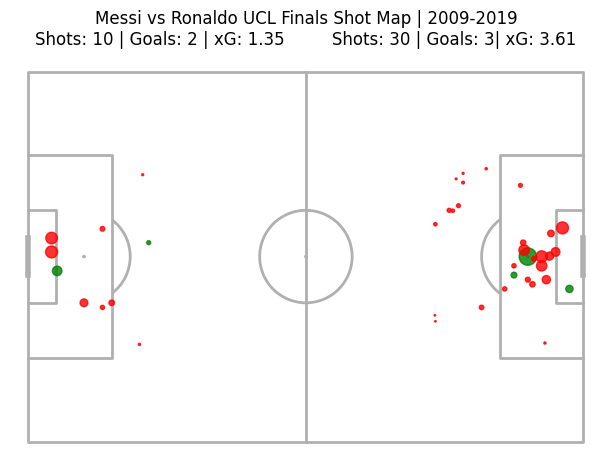

In [383]:
pitch = Pitch()
fig, ax = pitch.draw()

ronaldo_shots = all_shots[all_shots['player_name'] == 'Cristiano Ronaldo dos Santos Aveiro']

goals = ronaldo_shots[
    ronaldo_shots["outcome"] == "Goal"
]

others = ronaldo_shots[
    ronaldo_shots["outcome"] != "Goal"
]

pitch.scatter(
    goals['x'],
    goals['y'],
    s=goals['xg']*200,
    color = "green",
    alpha = .8,
    ax=ax
)

pitch.scatter(
    others['x'],
    others['y'],
    s=others['xg']*200,
    alpha = .8,
    color = 'red',
    ax=ax   
)

ronaldogoals = len(ronaldo_shots[ronaldo_shots["outcome"] == "Goal"])
xg = ronaldo_shots["xg"].sum()




messi_shots = all_shots[all_shots['player_name'] == 'Lionel Andrés Messi Cuccittini']

messigoals = messi_shots[
    messi_shots["outcome"] == "Goal"
]

messiothers = messi_shots[
    messi_shots["outcome"] != "Goal"
]

pitch.scatter(
    120 - messigoals['x'],
    80 - messigoals['y'],
    s=messigoals['xg']*200,
    color = "green",
    alpha = .8,
    ax=ax
)

pitch.scatter(
    120 - messiothers['x'],
    80 - messiothers['y'],
    s=messiothers['xg']*200,
    alpha = .8,
    color = 'red',
    ax=ax   
)

messigoals = len(messi_shots[messi_shots["outcome"] == "Goal"])
messixg = messi_shots["xg"].sum()

plt.title(
    f"Messi vs Ronaldo UCL Finals Shot Map | 2009-2019\nShots: {len(messi_shots)} | Goals: {messigoals} | xG: {messixg:.2f}         Shots: {len(ronaldo_shots)} | Goals: {ronaldogoals}| xG: {xg:.2f}"
)
plt.savefig('shotprofile/messivronaldo')
plt.show()

In [384]:
metrics = pd.DataFrame({
    'Metric': ['Shots','Goals', 'Players', 'Players (5+ shots)', 'Seasons'],
    'Value': [len(allshots), (allshots['outcome'] == 'Goal').sum(), (allshots["player_name"].nunique()), len(valid_players), '2009-2019']
})
metrics

,Metric,Value
0,Shots,355
1,Goals,35
2,Players,114
3,Players (5+ shots),20
4,Seasons,2009-2019


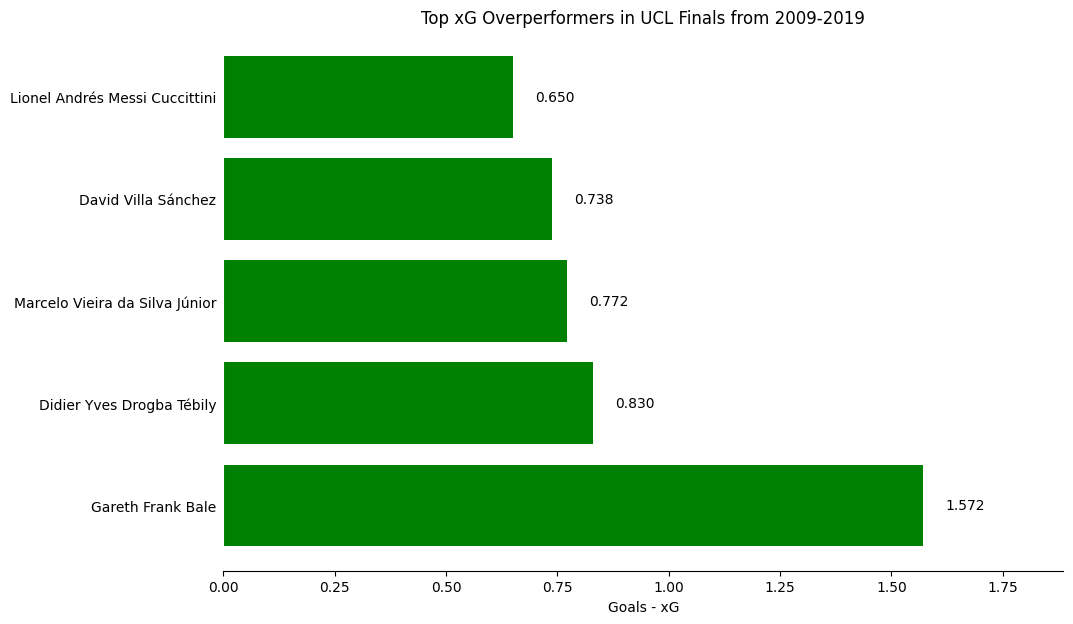

In [385]:
fig, ax = plt.subplots(figsize=(12, 7))

data['Goals - xG']

overperformance = data['Goals - xG'].sort_values(ascending= False)


bars = plt.barh(overperformance.head().index, overperformance.head().values, color='green', height= 0.8)
plt.xlabel("Goals - xG")

for bar in bars:
    value = bar.get_width()
    x_position = 0.3 if value < 0 else value + 0.05

    plt.text(x_position, bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center')

plt.xlim(right=overperformance.values.max() * 1.2)
plt.axvline(0, color='white')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.subplots_adjust(left=0.2)
ax.tick_params(axis='y', length=0)


ax.tick_params(axis='y', pad=5)
plt.subplots_adjust(left=0.2)
plt.title('Top xG Overperformers in UCL Finals from 2009-2019')

plt.savefig('shotprofile/xG-Overperformance')


plt.show()



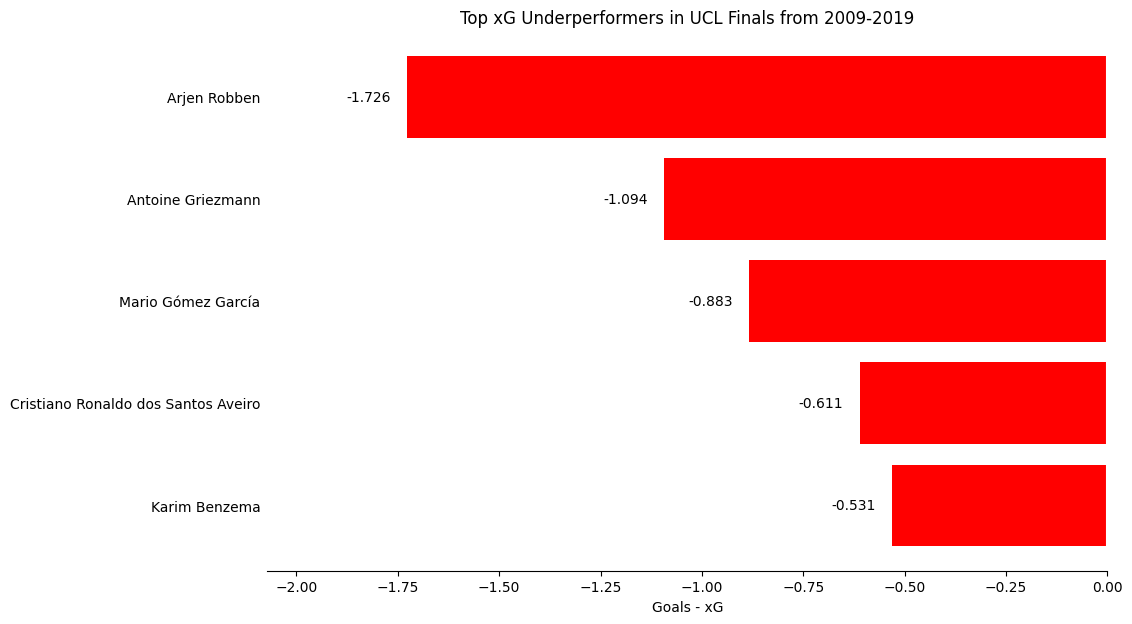

In [386]:
fig, ax = plt.subplots(figsize=(12, 7))
bars = plt.barh(overperformance.tail().index, overperformance.tail().values, color='red', height= 0.8)
plt.xlabel("Goals - xG")

for bar in bars:
    value = bar.get_width()
    x_position = value-0.15

    plt.text(x_position, bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center')

plt.xlim(left=overperformance.values.min() * 1.2)
plt.axvline(0, color='white')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.subplots_adjust(left=0.2)
ax.tick_params(axis='y', length=0)

plt.title('Top xG Underperformers in UCL Finals from 2009-2019')

plt.savefig('shotprofile/xG-Underperformance')


ax.tick_params(axis='y', pad=5)
plt.subplots_adjust(left=0.2)


In [387]:
overperformance = data['Goals - xG'].sort_values(ascending= False)
overperformance.head()

player_name
Gareth Frank Bale                 1.571826
Didier Yves Drogba Tébily         0.830154
Marcelo Vieira da Silva Júnior    0.772267
David Villa Sánchez               0.738085
Lionel Andrés Messi Cuccittini    0.649971
Name: Goals - xG, dtype: float64

In [388]:
overperformance.tail()

player_name
Karim Benzema                         -0.530788
Cristiano Ronaldo dos Santos Aveiro   -0.611228
Mario Gómez García                    -0.883414
Antoine Griezmann                     -1.093676
Arjen Robben                          -1.726049
Name: Goals - xG, dtype: float64

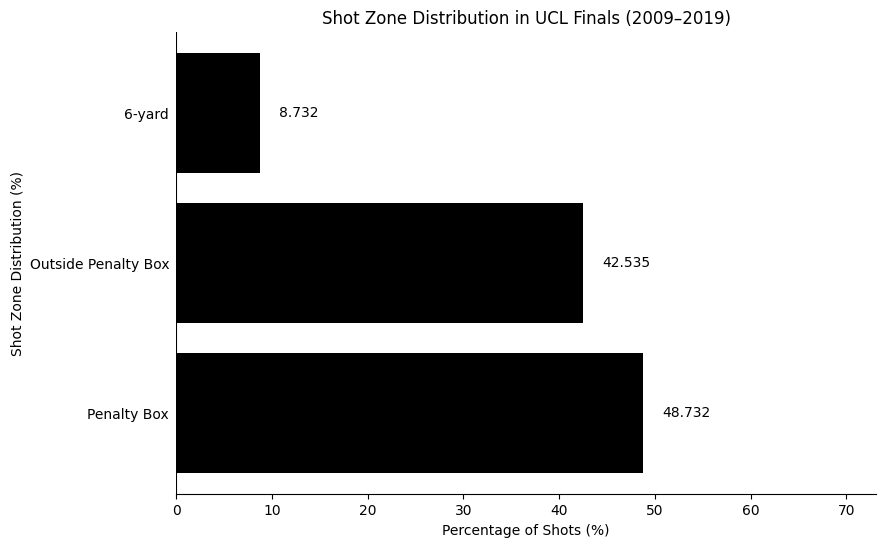

In [389]:
shotpercentage = (allshotlocation['zone'].value_counts(normalize=True)*100).round(3)
shotpercentage

fig, ax = plt.subplots(figsize=(10, 6))
bars = plt.barh(shotpercentage.index,shotpercentage.values, color='black')
plt.xlabel("Percentage of Shots (%)")

for bar in bars:
    value = bar.get_width()
    x_position = value + 2

    plt.text(x_position, bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center')

plt.xlim(right=shotpercentage.values.max() * 1.5)
plt.axvline(0, color='black')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.subplots_adjust(left=0.2)
ax.tick_params(axis='y', length=0)

plt.ylabel('Shot Zone Distribution (%)')
plt.title('Shot Zone Distribution in UCL Finals (2009–2019)')

plt.savefig('shotprofile/shotzone-percentage')


ax.tick_params(axis='y', pad=5)
plt.subplots_adjust(left=0.2)

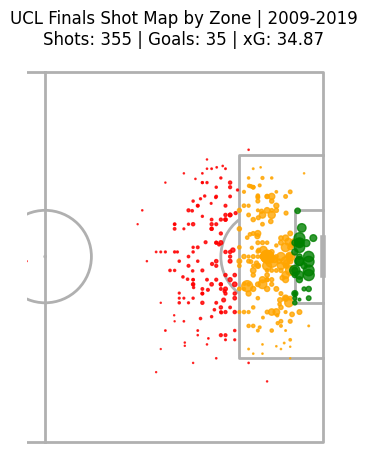

In [390]:
pitch = Pitch(half = True)
fig, ax = pitch.draw()

outsidepenalty = allshots[allshotlocation['zone'] == 'Outside Penalty Box']

pitch.scatter(
    outsidepenalty['x'],
    outsidepenalty['y'],
    s=outsidepenalty['xg']*100,
    color = "red",
    alpha = .8,
    ax=ax
)


inpenalty = allshots[allshotlocation['zone'] == 'Penalty Box']

pitch.scatter(
    inpenalty['x'],
    inpenalty['y'],
    s=inpenalty['xg']*100,
    color = "orange",
    alpha = .8,
    ax=ax
)

sixyard = allshots[allshotlocation['zone'] == '6-yard']

pitch.scatter(
    sixyard['x'],
    sixyard['y'],
    s=sixyard['xg']*100,
    color = "green",
    alpha = .8,
    ax=ax 
)


outsidegoals = len(outsidepenalty[outsidepenalty["outcome"] == "Goal"])
outxg = outsidepenalty["xg"].sum()
ingoals = len(inpenalty[inpenalty["outcome"] == "Goal"])
inxg = inpenalty["xg"].sum()
sixyardgoals = len(sixyard[sixyard["outcome"] == "Goal"])
sixxg = sixyard["xg"].sum()

totalxg = outxg + inxg + sixxg
totalgoals = outsidegoals + ingoals + sixyardgoals

plt.title(
    f"UCL Finals Shot Map by Zone | 2009-2019\nShots: {len(allshots)} | Goals: {totalgoals} | xG: {totalxg:.2f}"
)

plt.savefig('shotprofile/shotzone-scatter')
plt.show()